# Minimal Workflow Demonstration

In [1]:
import superstats as sup
import numpy as np

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/lschumacher/.local/share/uv/python/cpython-3.13.14-macos-aarch64-none/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:bayesflow:Using backend 'jax'


## Constants

In [2]:
# number of observations per dataset
NUM_STEPS = 100

## Specify an Observation Model

In this demonstration, we use the Diffusion Decision Model (DDM), which is already implemented in Superstats.
The Diffusion Decision Model (DDM) simulates response time and choice data using:

- **v** (drift rate): speed/direction of evidence accumulation
- **a** (boundary separation): caution — distance between decision thresholds
- **tau** (non-decision time): time for encoding + motor response
- **bias** (starting point): initial bias toward one boundary

In [3]:
obs_model = sup.simulation.sample_ddm

## Specify a Joint Prior

Each model parameter can be specified via the following options:
- A `StochasticTransition` $\rightarrow$ `local_param` (time-varying parameter, estimated) & `hyper_param` (time-invariant parameter, estimated)
- A `DeterministicTransition` $\rightarrow$ `deterministic_param` (time-varying parameter, not estimated) & `hyper_param` (time-invariant parameter, estimated)
- A `Prior` $\rightarrow$ `shared_param` (time-invariant, estimated)
- A `scalar` $\rightarrow$ `fixed_param` (time-varying, not estimated)

Here, we use:

- v: A Gaussian random walk as a `StochasticTransition`, with default hyperpriors for `sigma` (scale for noise) and `delta` (drift)
- a: A `DeterministicTransition` linear trend model, with default hyperpriors `slope`
- tau: A halfnormal `Prior` leading to an estimated parameter shared across steps (i.e., time-invariant)
- bias: A fixed `scalar` parameter that is both time-invariant and not estimated

For all parameters with a `transition` we need to specify bounds.

In `StochasticTransition`, trajectories are generated in an unconstrained space and then transformed via a scaled sigmoid function, so be cautious when specifying `initial_prior`, as it is specified in the unconstrained space.

In `DeterministicTransition`, trajectories simply get clipped to ensure staying within bounds.

In [4]:
joint_prior = sup.JointPrior(
    v = sup.transition.RandomWalk(bounds=(-6.0, 6.0)),
    a = sup.transition.Linear(
        bounds=(0.2, 4.0),
        intercept=sup.Prior("normal", loc=2.0, scale=0.5)
    ),
    tau = sup.Prior("halfnormal", scale=0.5),
    bias = 0.5
)

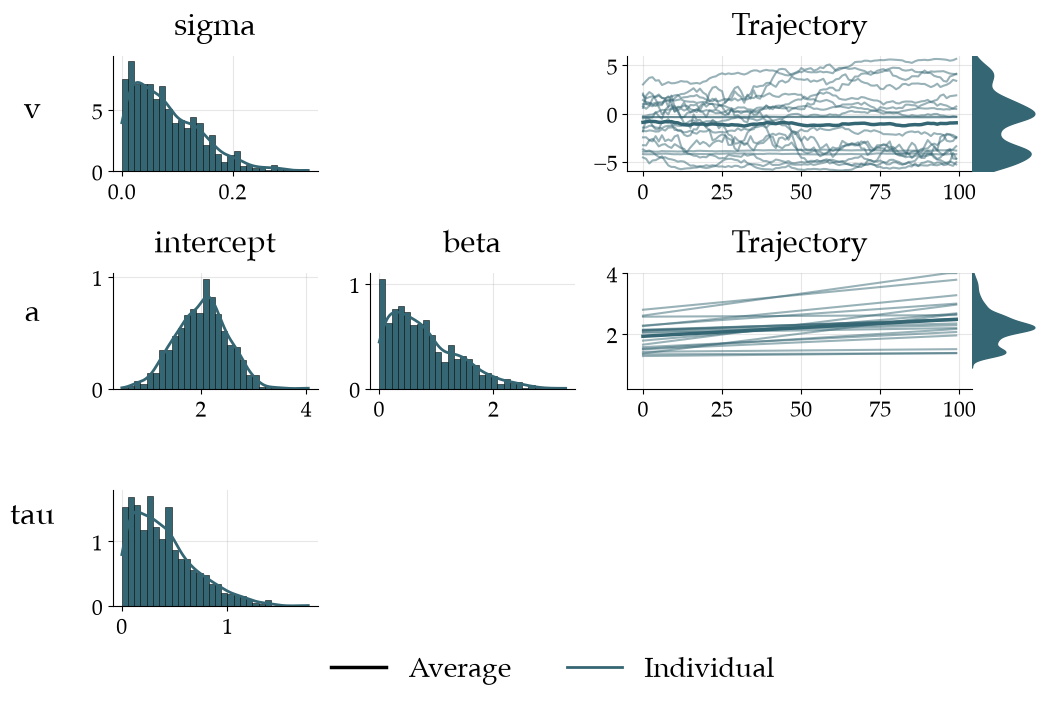

In [5]:
fig = joint_prior.plot_joint_prior(
    num_steps=NUM_STEPS,
    num_trajectories=20,
    figsize=(10, 6.5)
)

## Specify a Model

Combine the prior and simulator into a model. Additionally, we can specify a missingness process and a contamination process.

Missing-at-random is already implemented (`missing="random"`). We can even specify a prior on the missing probability so that each dataset has a different missing proportion (though this proportion itself is not estimated).

Similarly, we can specify a contamination process (`contamination="random_choice"`) and, if desired, estimate the probability of contamination.

In [ ]:
model = sup.Model(
    prior=joint_prior,
    simulator=obs_model,
    missing=None,
    contamination=None
)

Generate 10 prior samples and simulate 10 datasets, each with 100 observations.


In [ ]:
sim_data = model.sample(batch_size=10, num_steps=NUM_STEPS)

In [8]:
print(
    "Dict keys: ", sim_data.keys(), "\n",
    "Shape of response_time: ", sim_data["response_time"].shape, "\n",
    "Shape of a time-varying param: ", sim_data["v"].shape, "\n",
    "Shape of a time-invariant param: ", sim_data["v_sigma"].shape, "\n",
    sep=""
)

Dict keys: dict_keys(['response_time', 'choice', 'time_steps', 'v', 'a', 'v_sigma', 'a_intercept', 'a_beta', 'tau'])
Shape of response_time: (10, 100)
Shape of a time-varying param: (10, 100, 1)
Shape of a time-invariant param: (10, 1)



Generate 12 prior samples and simulate 12 datasets, each with 100 observations.

Plot response times (`data_dim=0`) as distributions (`kind="dist"`), with one panel per dataset (`aggregation=None`).

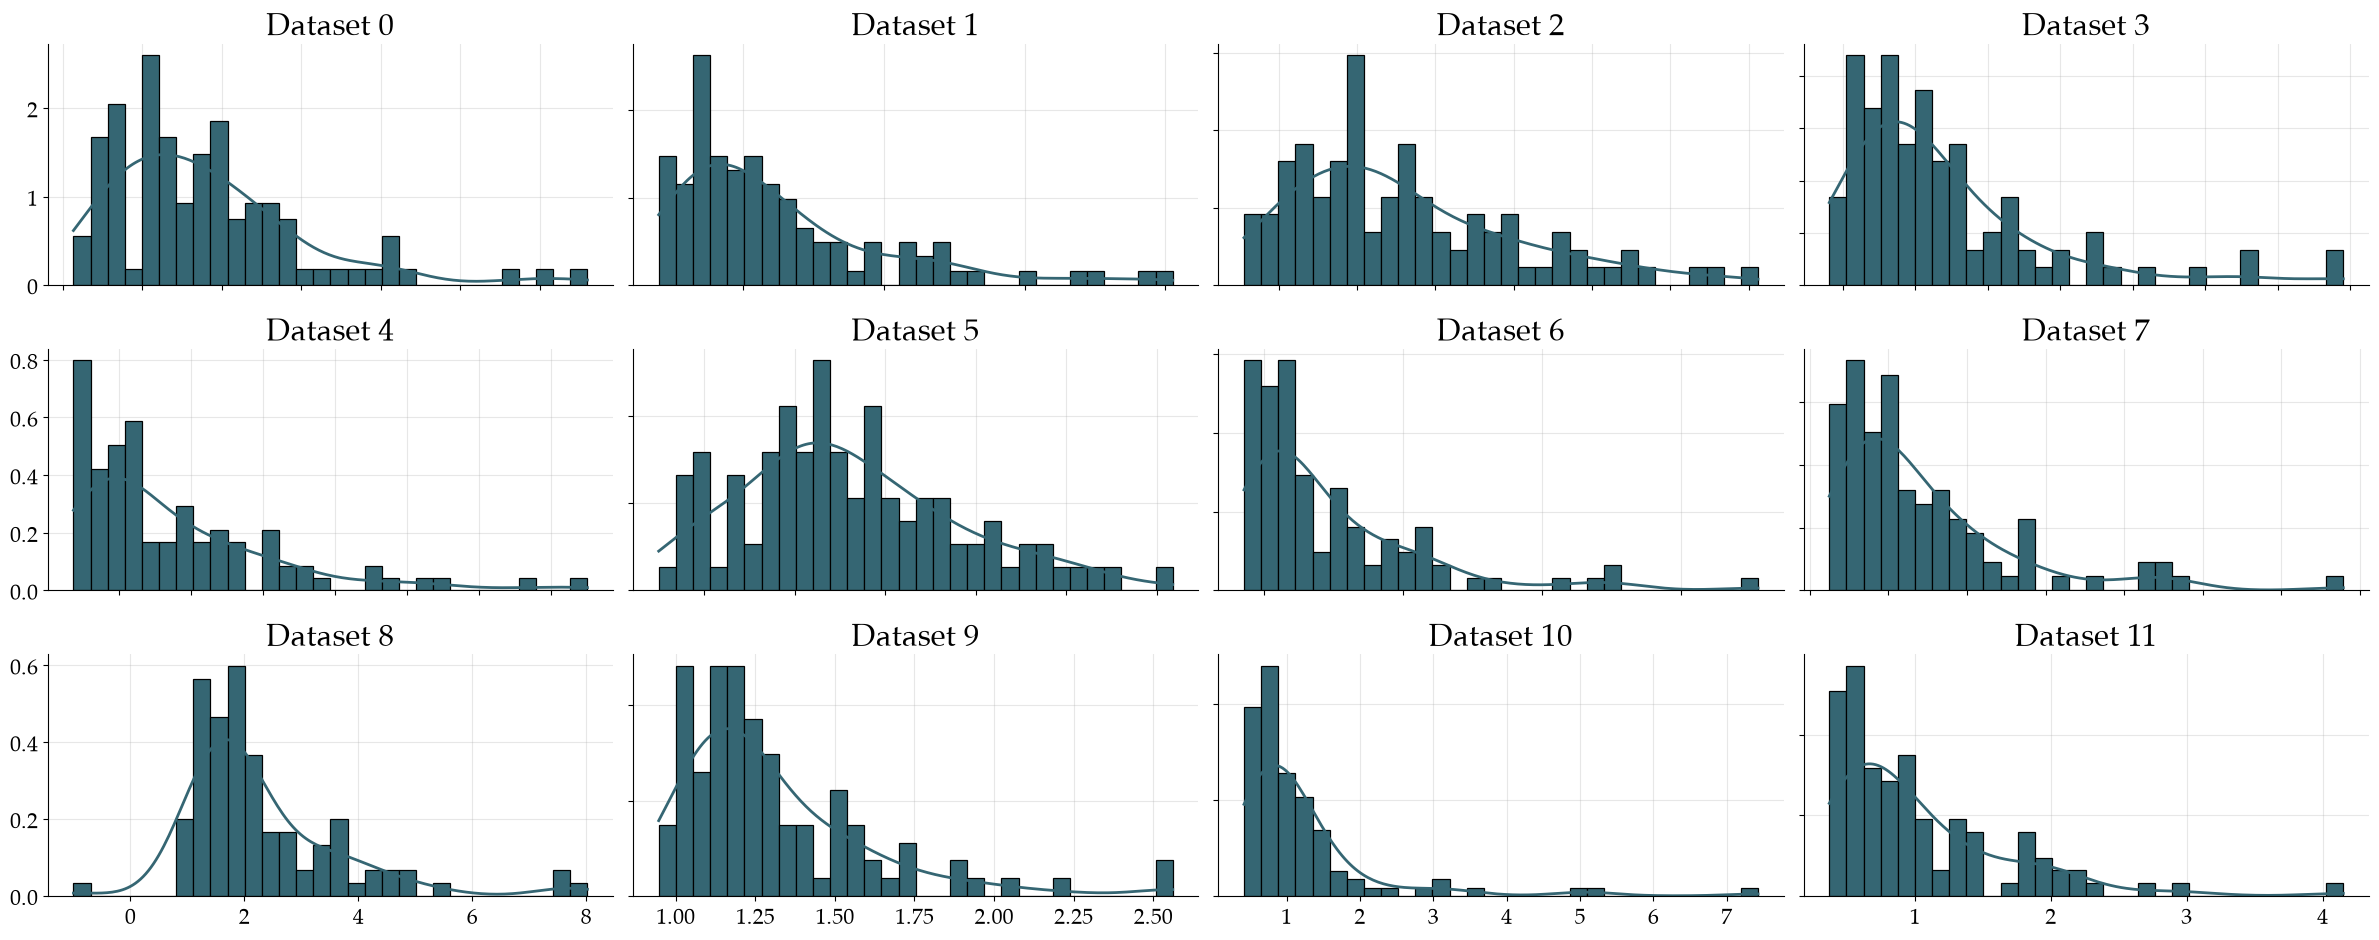

In [ ]:
fig = model.plot_push_forward(
    num_sim=12,
    num_steps=NUM_STEPS,
    data_dim=0,
    kind="dist",
    aggregation=None,
    num_cols=4
)

## Set up amortized Bayesian Workflow 

In [ ]:
workflow = sup.Workflow(
    model=model,
    checkpoint_filepath="checkpoints/minimal_demo",
    summary_network=sup.networks.RecurrentNet(),
    inference_network="coupling"
)

Here, users can provide summary and inference networks. Default networks are used if nothing is provided.

## Approximator Training

Choose either offline or online training

### Offline Training

Use offline training for fast iteration of the model develop and verification cicle.

In [ ]:
train_data = model.sample(
    batch_size=20_000,
    num_steps=NUM_STEPS,
    tile_to_steps=True
)
val_data = model.sample(
    batch_size=100,
    num_steps=NUM_STEPS,
    tile_to_steps=True
)

In [ ]:
history = workflow.fit_offline(
    data=train_data,
    validation_data=val_data,
    epochs=50,
    batch_size=32
)

### Online Training

Use online training for final maximal performance.

In [ ]:
history = workflow.fit_online(
    num_steps=100, epochs=50,
    num_batches_per_epoch=1000,
    batch_size=32
)

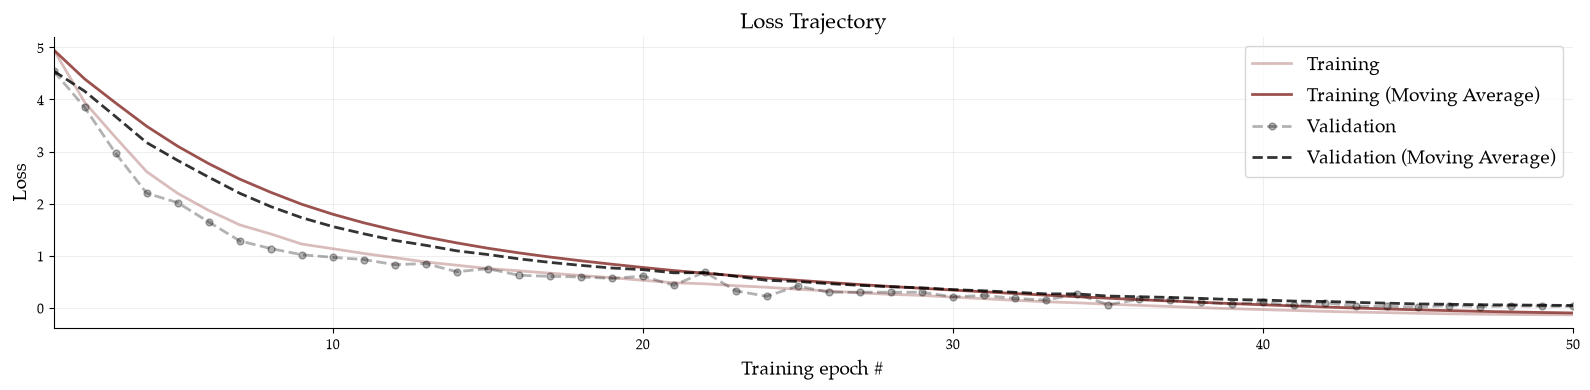

In [13]:
fig = workflow.plot_history(workflow.history)

## Model Verification

Simulate some data for verification

In [ ]:
targets = workflow.model.sample(
    batch_size=250,
    num_steps=NUM_STEPS,
)

Fit the model to the simulated data

In [ ]:
samples = workflow.sample(
    data=targets,
    num_samples=300,
    batch_size=8
)

### Time-varying Parameters

Plot four diagnostic metrics for the time-varying parameters across time:
1. Pearson correlation between true parameter and posterior median
2. Normalized root mean squared error between true parameter and posterior median
3. Posterior contraction
4. Simulation-based calibration error

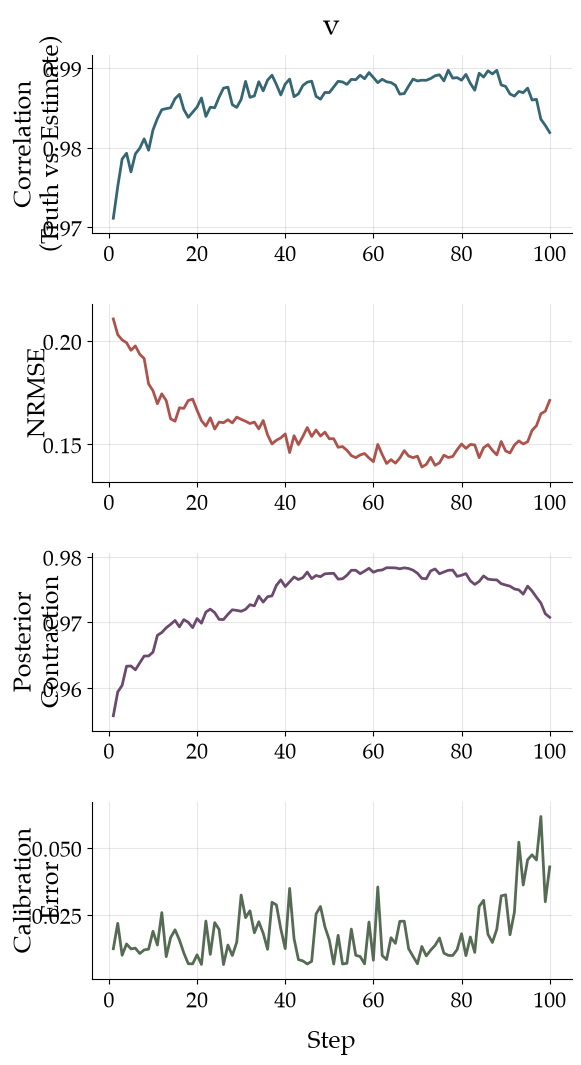

In [16]:
fig = workflow.verify_time_varying(
    targets=targets,
    estimates=samples
)

### Time-invariant Parameters

Plot recovery and simulation-based calibration for time-invariant parameters

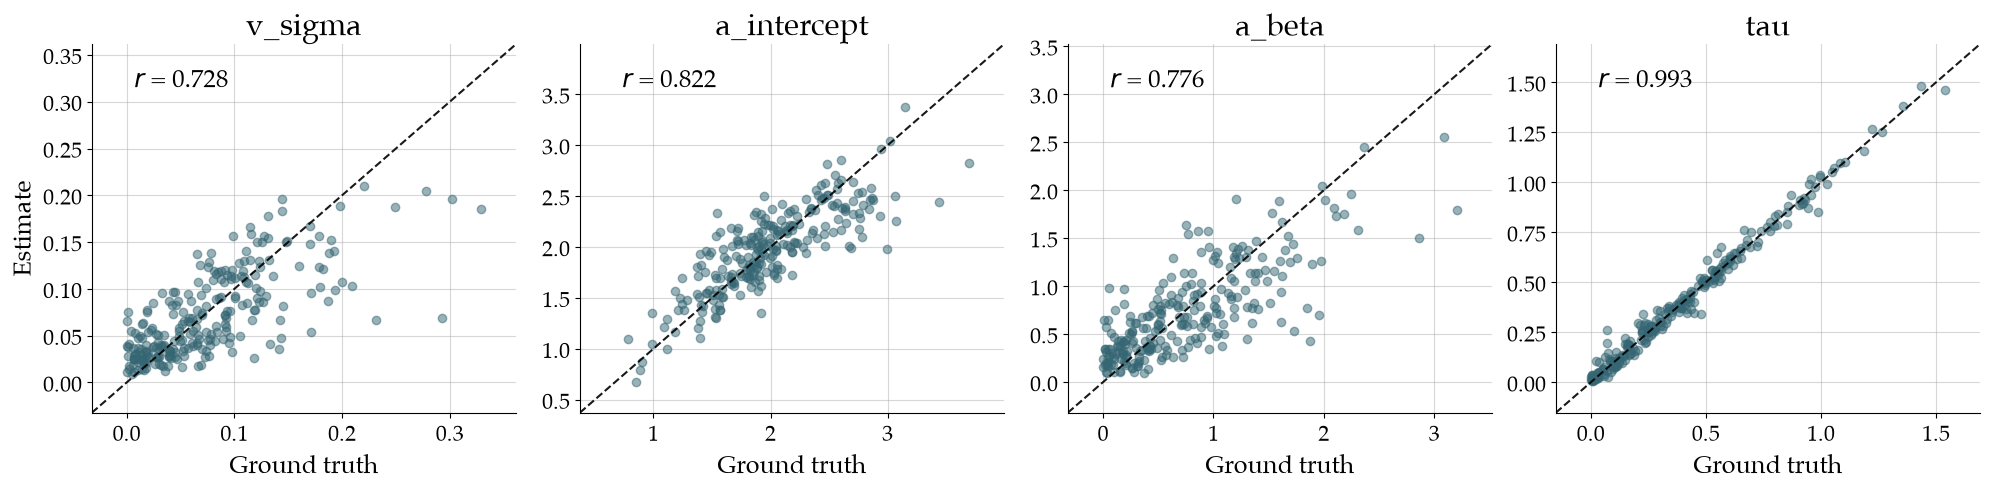

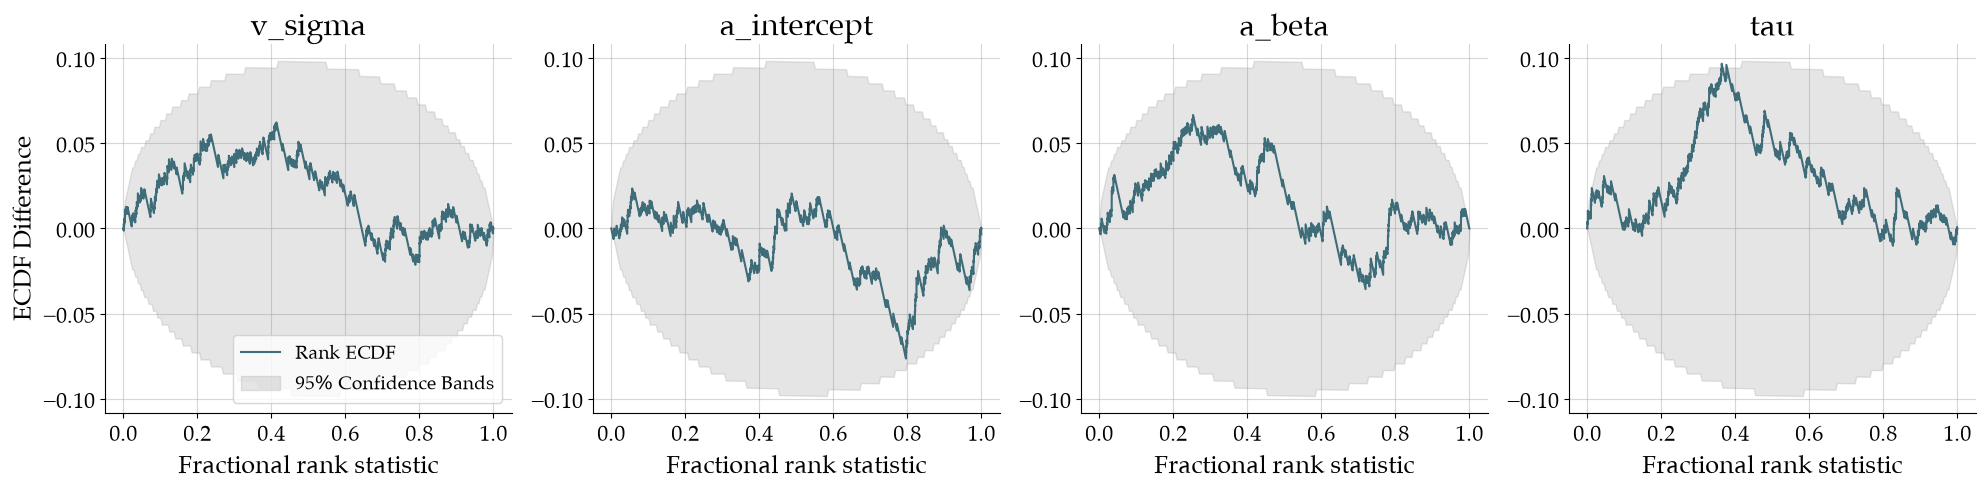

In [17]:
fig_recovery, fig_calibration = workflow.verify_time_invariant(
    estimates=samples,
    targets=targets,
    uncertainty_agg=None
)

## Fit Data

Here we could use real data and just bring it into the same shape as the simulated. However, we just use simulated data here and treat it as if it was real data.

In [ ]:
num_subject = 50

data = workflow.model.sample(
    batch_size=num_subject,
    num_steps=NUM_STEPS
)

In [ ]:
samples = workflow.sample(
    data=data,
    num_samples=500
)

## Posterior Re-simulation

In [20]:
resim_data = workflow.resimulate_posterior(
    samples,
    num_sims=5
)

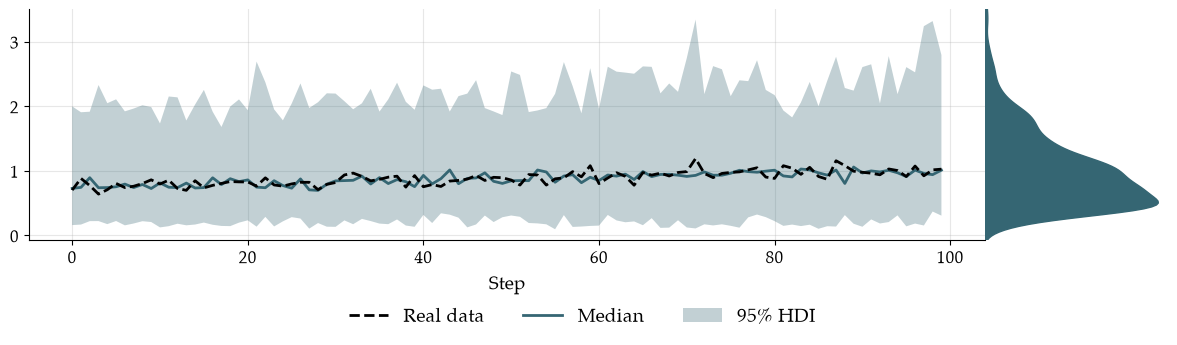

In [21]:
fig = sup.diagnostics.plot_posterior_resimulation(
    pred_data=resim_data,
    real_data=data,
    aggregation=np.median,
    aggregate_strategy="no_epistemic",
)

## Posterior Estimates

## Time-varying

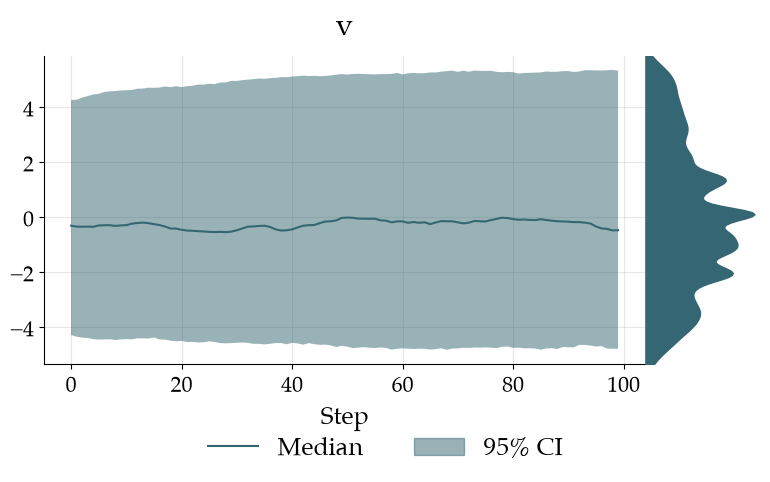

In [24]:
fig = workflow.plot_time_varying_posterior(
    estimates=samples,
    aggregation=np.median,
    num_cols=1
)

## Time-invariant

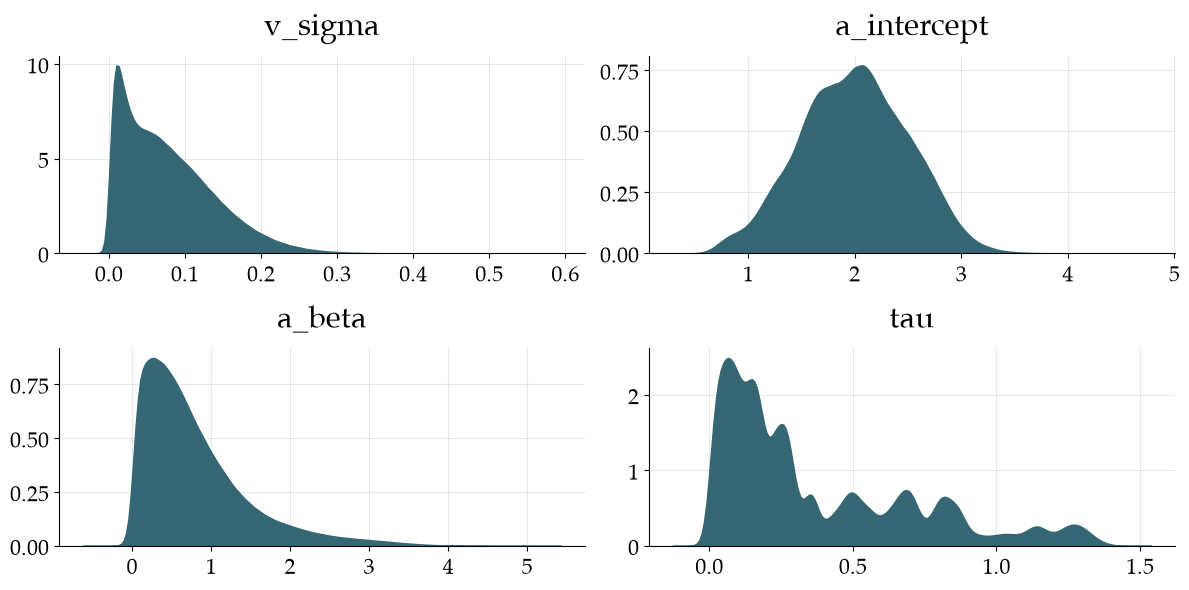

In [23]:
fig = workflow.plot_time_invariant_posterior(
    estimates=samples,
    aggregation=np.median
)